In [ ]:
import polars as pl
df=pl.read_parquet("../data/processed/train_features.parquet")
df.head()

In [ ]:
COLUMNS_TO_KEEP = [
    "tpep_pickup_datetime",
    "tpep_dropoff_datetime",
    "PULocationID",
    "trip_distance",
    "passenger_count",
    "fare_amount",
    "total_amount",
]


In [ ]:


df = pl.read_parquet(
    "../data/processed/train.parquet"
)
df.describe()

In [ ]:
df=df.rename({"tpep_pickup_datetime":"pickup_dt","tpep_dropoff_datetime":"dropoff_dt"})

In [ ]:
df.head()

In [ ]:
df.describe()

In [ ]:
df=df.drop_nulls(subset=['pickup_dt'])

In [ ]:
df=df.filter(
    (pl.col("trip_distance")>0) &
    (pl.col("fare_amount")>0 ) &
    (pl.col("PULocationID").is_between(1,263)) &
    (pl.col("pickup_dt").dt.year()==2025)
)

In [ ]:
df=df.with_columns(
    pl.col("pickup_dt")
    .dt.truncate("1h")
    .alias("pickup_hour")
)

In [ ]:
agg_df=df.group_by(["pickup_hour","PULocationID"]).len().rename({"len":"trip_count"})

In [ ]:
agg_df[13500:135510]

In [ ]:
agg_df.sort(['pickup_hour']).tail()

In [ ]:
agg_df.shape

In [ ]:
all_hours=pl.datetime_range(
    start=df['pickup_hour'].min().replace(minute=0,second=0,microsecond=0),
    end=df['pickup_hour'].max().replace(minute=0,second=0,microsecond=0),
    interval='1h',
    eager=True
).alias("pickup_hour")


In [ ]:
all_hours

In [ ]:
all_zones=pl.Series("PULocationID",list(range(1,264)))


In [ ]:
full_grid=all_hours.to_frame().join(all_zones.to_frame(),how='cross')

In [ ]:
import numpy as np

In [ ]:
result=(
    full_grid
    .join(df,on=['pickup_hour',"PULocationID"],how='left')
    .with_columns(pl.col("trip_count").fill_null(0))
    .sort(['pickup_hour',"PULocationID"])
)

In [ ]:
result

In [ ]:
def add_time_features(df:pl.DataFrame)->pl.DataFrame:
    time_df=df.with_columns(
        [
            pl.col("pickup_hour")
            .dt.hour()
            .alias("hour_of_day"),

           pl.col("pickup_hour")
            .dt.weekday()
            .alias("day_of_week"),

            pl.col("pickup_hour")
            .dt.month()
            .alias("month"),
            
            (
                2 * np.pi *
                pl.col("pickup_hour").dt.hour() / 24
            )
            .sin()
            .alias("hour_sin"),

            (
                2 * np.pi *
                pl.col("pickup_hour").dt.hour() / 24
            )
            .cos()
            .alias("hour_cos"),

            (
                2 * np.pi *
                pl.col("pickup_hour").dt.weekday() / 7
            )
            .sin()
            .alias("dow_sin"),

            (
                2 * np.pi *
                pl.col("pickup_hour").dt.weekday() / 7
            )
            .cos()
            .alias("dow_cos"),
        ]
    )
    return time_df

In [ ]:
def add_lag_features(df:pl.DataFrame)->pl.DataFrame:
    lag_df=df.with_columns(
        [
            pl.col("trip_count")
            .shift(1)
            .over("PULocationID")
            .alias("lag_1h"),

            pl.col("trip_count")
            .shift(24)
            .over("PULocationID")
            .alias("lag_24h"),

            pl.col("trip_count")
            .shift(168)
            .over("PULocationID")
            .alias("lag_168h"),
        ]
    )
    return lag_df

In [ ]:
def add_rolling_features(df:pl.DataFrame)->pl.DataFrame:
    rolling_df=df.with_columns(
        [
            pl.col("trip_count")
            .shift(1)
            .rolling_mean(window_size=3)
            .over("PULocationID")
            .alias("rolling_mean_3h"),

            pl.col("trip_count")
            .shift(1)
            .rolling_mean(window_size=24)
            .over("PULocationID")
            .alias("rolling_mean_24h"),

            pl.col("trip_count")
            .shift(1)
            .rolling_mean(168)
            .over("PULocationID")
            .alias("rolling_mean_168h"),

            pl.col("trip_count")
            .shift(1)
            .rolling_std(window_size=24)
            .over("PULocationID")
            .alias("rolling_std_24h"),

            pl.col("trip_count")
            .shift(1)
            .rolling_std(168)
            .over("PULocationID")
            .alias("rolling_std_168h")
        ]
    )
    return rolling_df

In [ ]:

def drop_nulls(df:pl.DataFrame)->pl.DataFrame:
    df=df.drop_nulls(subset=[
        'lag_1h',
        'lag_24h',
        'lag_168h',
        'rolling_mean_3h',
        'rolling_mean_24h',
        'rolling_mean_168h',
        'rolling_std_24h,'
        'rolling_std_168h'
        ])
    return df

In [ ]:
TARGET_COL = "trip_count"
LOCATION_COL = "PULocationID"
TIME_COL = "pickup_hour"

In [ ]:
def build_features(df:pl.DataFrame)->pl.DataFrame:
    df=df.sort([LOCATION_COL,TIME_COL])
    df=add_time_features(df)
    df=add_lag_features(df)
    df=add_rolling_features(df)
    df=drop_nulls(df)
    return df

In [ ]:
featured_df=build_features(result)

In [ ]:
import polars as pl

In [ ]:
df=pl.read_parquet("../data/processed/train_features.parquet")

In [ ]:
df

In [ ]:
import mlflow
import mlflow.xgboost
import xgboost as xgb
import polars as pl
import numpy as np
from pathlib import Path
VALIDATION_SPLIT_DATE = "2023-05-01" 
MLFLOW_TRACKING_URI = "http://localhost:5000"
MLFLOW_EXPERIMENT = "ride-demand-forecast"
RANDOM_SEED = 42
XGB_PARAMS = {
    'objective':"reg:squarederror",
    "n_estimators": 2000,
    "learning_rate": 0.03,
    "max_depth": 6,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "random_state": RANDOM_SEED,
}
from datetime import datetime

VALIDATION_SPLIT_DATE = datetime(
    2025, 6, 1, 0, 0, 0
)
TARGET_COL = "trip_count"

In [ ]:
import mlflow

print(mlflow.get_tracking_uri())

In [ ]:
from mlflow.tracking import MlflowClient

client = MlflowClient()

model = client.get_model_version(
    name="ride_demand_xgboost",
    version="1"   # replace with your version
)

print(model.source)

In [ ]:
import polars as pl
df1=pl.read_parquet("../data/reference/reference.parquet")
df1

total_demand,avg_demand,std_demand,peak_demand
u32,f64,f64,u32
1098,4.174905,13.517582,146
390,1.48289,4.270292,37
206,0.78327,2.353044,17
169,0.642586,2.008002,18
202,0.768061,1.602541,9
…,…,…,…
8688,33.034221,69.154013,354
7837,29.798479,63.528088,428
7864,29.901141,69.50192,510


In [10]:
import polars as pl
df1=pl.read_parquet("../data/reference/reference_original.parquet")
df1

total_demand,avg_demand,std_demand,peak_demand
u32,f64,f64,u32
1098,4.174905,13.517582,146
390,1.48289,4.270292,37
206,0.78327,2.353044,17
169,0.642586,2.008002,18
202,0.768061,1.602541,9
…,…,…,…
8688,33.034221,69.154013,354
7837,29.798479,63.528088,428
7864,29.901141,69.50192,510


In [9]:
import polars as pl
df2=pl.read_parquet("../data/reference/reference_current.parquet")
df2

total_demand,avg_demand,std_demand,peak_demand
u32,f64,f64,u32
1098,4.174905,13.517582,146
390,1.48289,4.270292,37
206,0.78327,2.353044,17
169,0.642586,2.008002,18
202,0.768061,1.602541,9
…,…,…,…
9145,34.771863,84.280573,483
8526,32.418251,74.535815,374
7530,28.631179,64.129617,358


In [13]:
MLFLOW_TRACKING_URI = "http://localhost:5000"
MLFLOW_EXPERIMENT = "ride-demand-forecast"
import mlflow


mlflow.set_tracking_uri(MLFLOW_TRACKING_URI)
client = mlflow.tracking.MlflowClient()
experiment = client.get_experiment_by_name(MLFLOW_EXPERIMENT)
runs = client.search_runs(
    experiment_ids=[experiment.experiment_id],
    order_by=["start_time ASC"]
)

for run in runs:
    rmse = run.data.metrics.get("val_rmse", None)
    promoted = run.data.metrics.get("promoted", None)
    name = run.info.run_name or "unnamed"
    
    if rmse is not None:
        print(f"{name} | RMSE: {rmse:.4f} | Promoted: {promoted}")
    else:
        print(f"{name} | RMSE: N/A | Promoted: {promoted}")

bold-deer-622 | RMSE: N/A | Promoted: None
nosy-boar-114 | RMSE: N/A | Promoted: None
serious-ray-434 | RMSE: N/A | Promoted: None
fearless-auk-11 | RMSE: N/A | Promoted: None
upbeat-shrike-689 | RMSE: N/A | Promoted: None
gregarious-goat-64 | RMSE: N/A | Promoted: None
efficient-ape-275 | RMSE: N/A | Promoted: None
charming-hound-279 | RMSE: N/A | Promoted: None
traveling-bird-779 | RMSE: N/A | Promoted: None
aged-stoat-976 | RMSE: N/A | Promoted: None
caring-swan-543 | RMSE: N/A | Promoted: None
likeable-roo-981 | RMSE: N/A | Promoted: None
gentle-pug-403 | RMSE: N/A | Promoted: None
funny-hawk-973 | RMSE: N/A | Promoted: None
clumsy-shrike-341 | RMSE: N/A | Promoted: None
languid-shrike-825 | RMSE: N/A | Promoted: None
mercurial-stork-909 | RMSE: N/A | Promoted: None
burly-elk-725 | RMSE: N/A | Promoted: None
clean-sheep-102 | RMSE: N/A | Promoted: None
righteous-yak-887 | RMSE: N/A | Promoted: None
loud-seal-273 | RMSE: N/A | Promoted: None
upbeat-fox-366 | RMSE: N/A | Promoted: No

In [ ]:
import mlflow

mlflow.set_tracking_uri(
    "http://localhost:5000"
)

model = mlflow.xgboost.load_model(
    "models:/ride_demand_xgboost/latest"
)

In [ ]:
# src/features/schema.py
FEATURE_SCHEMA = {
    "hour_of_day":       {"dtype": "int8",    "min": 0,   "max": 23},
    "day_of_week":       {"dtype": "int8",    "min": 0,   "max": 6},
    "month":             {"dtype": "int8",    "min": 1,   "max": 12},

    # "is_weekend":        {"dtype": "bool",    "min": 0,   "max": 1},
    # "is_rush_hour":      {"dtype": "bool",    "min": 0,   "max": 1},

    "hour_sin":          {"dtype": "float64", "min": -1,  "max": 1},
    "hour_cos":          {"dtype": "float64", "min": -1,  "max": 1},

    "dow_sin":           {"dtype": "float64", "min": -1,  "max": 1},
    "dow_cos":           {"dtype": "float64", "min": -1,  "max": 1},

    "lag_1h":            {"dtype": "float64", "min": 0,   "max": None},
    "lag_24h":           {"dtype": "float64", "min": 0,   "max": None},
    "lag_168h":          {"dtype": "float64", "min": 0,   "max": None},

    "rolling_mean_3h":   {"dtype": "float64", "min": 0,   "max": None},
    "rolling_mean_24h":  {"dtype": "float64", "min": 0,   "max": None},
    "rolling_mean_168h": {"dtype": "float64", "min": 0,   "max": None},

    "rolling_std_24h":   {"dtype": "float64", "min": 0,   "max": None},
    "rolling_std_168h":  {"dtype": "float64", "min": 0,   "max": None},

    # "zone_avg_demand":   {"dtype": "float64", "min": 0,   "max": None},
    "zone_hour_avg":     {"dtype": "float64", "min": 0,   "max": None},
    "PULocationID":      {"dtype": "category", "min": 1,  "max": 263},
}
FEATURE_COLUMNS = list(FEATURE_SCHEMA.keys())


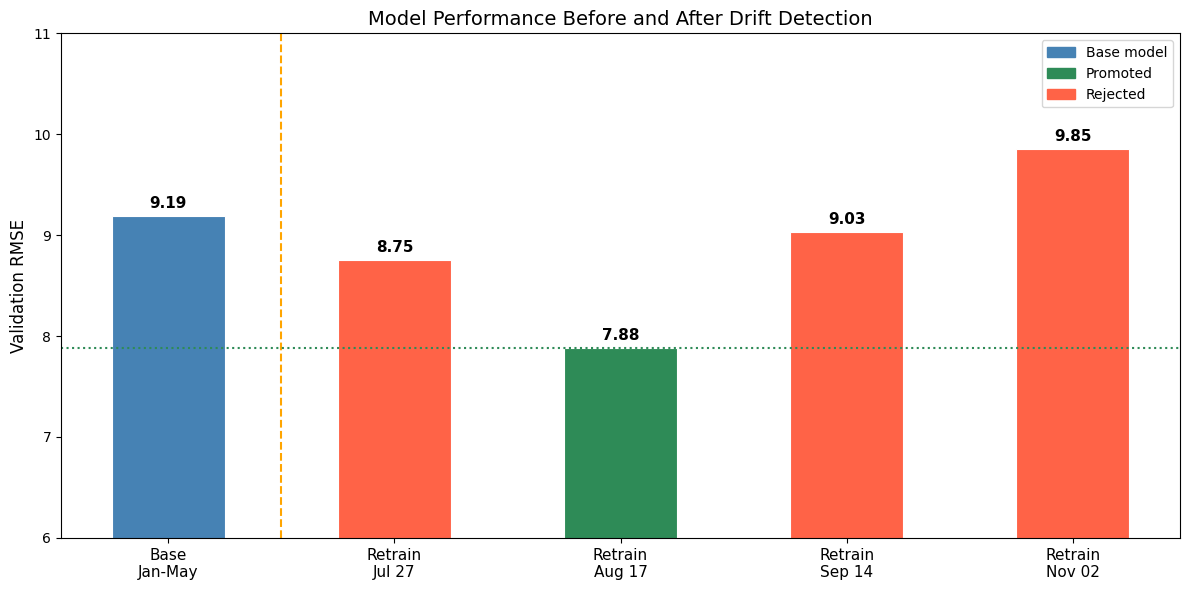

In [15]:
# notebooks/performance_analysis.ipynb

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

runs_data = [
    {"name": "Base\nJan-May", "date": "2025-05-01", "rmse": 9.19, "promoted": None},
    {"name": "Retrain\nJul 27",  "date": "2025-07-27", "rmse": 8.75, "promoted": 0},
    {"name": "Retrain\nAug 17",  "date": "2025-08-17", "rmse": 7.88, "promoted": 1},
    {"name": "Retrain\nSep 14",  "date": "2025-09-14", "rmse": 9.03, "promoted": 0},
    {"name": "Retrain\nNov 02",  "date": "2025-11-02", "rmse": 9.85, "promoted": 0},
]

fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(runs_data))
rmses = [r["rmse"] for r in runs_data]
colors = []
for r in runs_data:
    if r["promoted"] is None:
        colors.append("steelblue")    # base model
    elif r["promoted"] == 1:
        colors.append("seagreen")     # promoted
    else:
        colors.append("tomato")       # rejected

bars = ax.bar(x, rmses, color=colors, width=0.5, edgecolor="white", linewidth=0.8)

# add RMSE values on top of bars
for bar, rmse in zip(bars, rmses):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.05,
        f"{rmse:.2f}",
        ha="center", va="bottom", fontsize=11, fontweight="bold"
    )

# drift detection start line
ax.axvline(x=0.5, color="orange", linestyle="--", linewidth=1.5, label="Drift detection active")

# best model line
ax.axhline(y=7.88, color="seagreen", linestyle=":", linewidth=1.5, label="Best deployed model (7.88)")

ax.set_xticks(x)
ax.set_xticklabels([r["name"] for r in runs_data], fontsize=11)
ax.set_ylabel("Validation RMSE", fontsize=12)
ax.set_title("Model Performance Before and After Drift Detection", fontsize=14)
ax.set_ylim(6, 11)

# legend
patches = [
    mpatches.Patch(color="steelblue", label="Base model"),
    mpatches.Patch(color="seagreen",  label="Promoted"),
    mpatches.Patch(color="tomato",    label="Rejected"),
]
ax.legend(handles=patches, fontsize=10)

plt.tight_layout()
plt.savefig("../artifacts/plots/before_after_drift.png", dpi=150)
plt.show()

In [ ]:
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error,root_mean_squared_error,mean_absolute_percentage_error

def compute_metrics(y_true,y_pred)->dict:
    rmse=root_mean_squared_error(y_true=y_true,y_pred=y_pred)
    mae=mean_absolute_error(y_true=y_true,y_pred=y_pred)
    mask=y_true!=0
    mape=mean_absolute_percentage_error(y_true=y_true[mask],y_pred=y_pred[mask])

    return {"rmse":rmse,"mae":mae,"mape":mape}

from pathlib import Path
import numpy as np
import polars as pl
import matplotlib.pyplot as plt
from datetime import timedelta


def plot_predictions(
    val_df: pl.DataFrame,
    y_pred: np.ndarray,
    zone_id: int,
    title: str,
    save_path: Path,
) -> Path:

    pred_df = val_df.with_columns(
        pl.Series("prediction", y_pred)
    )

    zone_df = (
        pred_df
        .filter(pl.col("PULocationID") == zone_id)
        .sort("pickup_hour")
        .head(168)
    )

    if zone_df.is_empty():
        raise ValueError(
            f"No validation data found for zone {zone_id}"
        )

    hours = zone_df["pickup_hour"].to_list()
    y_true = zone_df["trip_count"].to_numpy()
    y_pred_zone = zone_df["prediction"].to_numpy()

    fig, ax = plt.subplots(figsize=(14, 6))

    ax.plot(
        hours,
        y_true,
        label="Actual",
        linewidth=2,
    )

    ax.plot(
        hours,
        y_pred_zone,
        label="Predicted",
        linewidth=2,
        linestyle="--",
    )

    rush_hours = {7, 8, 9, 17, 18, 19}

    for dt in hours:
        if dt.hour in rush_hours:
            ax.axvspan(
                dt,
                dt + timedelta(hours=1),
                alpha=0.08,
            )

    ax.set_title(
        f"{title} | Zone {zone_id}"
    )

    ax.set_xlabel("Pickup Hour")
    ax.set_ylabel("Trip Count")

    ax.legend()
    ax.grid(alpha=0.3)

    fig.autofmt_xdate()
    fig.tight_layout()

    save_path = Path(save_path)

    save_path.parent.mkdir(
        parents=True,
        exist_ok=True,
    )

    fig.savefig(
        save_path,
        dpi=150,
        bbox_inches="tight",
    )

    plt.close(fig)

    return save_path



In [ ]:
def load_training_data(df=pl.DataFrame)->tuple:
    # df=pl.read_parquet('../data/processed/train_features.parquet')

    train_df=df.filter(pl.col("pickup_hour")<VALIDATION_SPLIT_DATE)
    val_df=df.filter(pl.col("pickup_hour")>=VALIDATION_SPLIT_DATE)

    zone_hour_avg = (
        train_df
        .group_by(
            ["PULocationID", "hour_of_day"]
        )
        .agg(
            pl.mean("trip_count")
            .alias("zone_hour_avg")
        )
    )

    train_df = train_df.join(
        zone_hour_avg,
        on=["PULocationID", "hour_of_day"],
        how="left"
    )
    val_df = val_df.join(
        zone_hour_avg,
        on=["PULocationID", "hour_of_day"],
        how="left"
    )
  

    X_train=train_df.select(FEATURE_COLUMNS).to_pandas()
    y_train=train_df[TARGET_COL].to_pandas()
    X_val=val_df.select(FEATURE_COLUMNS).to_pandas()
    y_val=val_df[TARGET_COL].to_pandas()

    X_train['PULocationID']=X_train['PULocationID'].astype("category")
    X_val["PULocationID"]=X_val["PULocationID"].astype("category")

    return X_train,y_train,X_val,y_val,val_df


mlflow.set_tracking_uri(MLFLOW_TRACKING_URI)
mlflow.set_experiment(MLFLOW_EXPERIMENT)

X_train,y_train,X_val,y_val,val_df=load_training_data(featured_df)

with mlflow.start_run():
    mlflow.set_tags({
        "model":"XGBoost",
        "version":"0.1",
        "name":"ride_analysis_xgboost"
    })

    mlflow.log_params(
        XGB_PARAMS
    )

    model=xgb.XGBRegressor(
        **XGB_PARAMS,
        enable_categorical=True,
        tree_method='hist',
        early_stopping_rounds=50
    )

    model.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        verbose=100,
    )
    train_pred = model.predict(X_train)
    train_metrics = compute_metrics(y_train, train_pred)

    val_pred = model.predict(X_val)
    val_metrics = compute_metrics(y_val, val_pred)

    
    save_path=plot_predictions(val_df,val_pred,zone_id=200,save_path=Path("../artifacts/val_forecast.png"),title="validation actual vs prediction plot")
    train_metrics = {
        f"train_{k}": v
        for k, v in train_metrics.items()
    }

    val_metrics = {
        f"val_{k}": v
        for k, v in val_metrics.items()
    }
    lag1_rmse=root_mean_squared_error(
        y_val,
        X_val["lag_1h"]
    )

    lag24_rmse=root_mean_squared_error(
            y_val,
            X_val["lag_24h"]
        )
    lag168_rmse=root_mean_squared_error(
            y_val,
            X_val["lag_168h"]
        )
    
    baseline_metrics = {
    "baseline_lag1_rmse": lag1_rmse,
    "baseline_lag24_rmse": lag24_rmse,
        "baseline_lag168_rmse": lag168_rmse,
    }

    mlflow.log_metrics(baseline_metrics)
    mlflow.log_metrics(train_metrics)
    mlflow.log_metrics(val_metrics)

    mlflow.log_artifact(str(save_path))

    mlflow.xgboost.log_model(
        model,
        artifact_path="model",
            registered_model_name="ride_demand_xgb"
    )

    print(xgb.plot_importance(model))

